**Importation des bibliothèques**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

**Chargement des données**

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Nombre d'échantillons :", X.shape[0])
print("Nombre de caractéristiques :", X.shape[1])

Nombre d'échantillons : 569
Nombre de caractéristiques : 30


**Séparation Train/Test**

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("Train :", X_train.shape)
print("Test :", X_test.shape)

Train : (398, 30)
Test : (171, 30)


Normalisation

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Données normalisées avec succès.")

Données normalisées avec succès.


**ÉTAPE 1 : Expérimentation Manuelle**

In [5]:
# TEST MANUEL

valeur_choisie = 0.01

model = LogisticRegression(
    C=valeur_choisie,
    max_iter=10000
)

model.fit(X_train_scaled, y_train)

train_score = model.score(X_train_scaled, y_train)
test_score = model.score(X_test_scaled, y_test)

print("=" * 50)
print(f"Résultats pour C = {valeur_choisie}")
print("=" * 50)

print(f"Accuracy Train : {train_score:.4f}")
print(f"Accuracy Test  : {test_score:.4f}")

Résultats pour C = 0.01
Accuracy Train : 0.9523
Accuracy Test  : 0.9591


**ÉTAPE 2 : Automatisation**

In [6]:
C_values = [
    0.0001,
    0.001,
    0.01,
    0.1,
    1,
    10,
    100,
    1000
]

train_scores = []
test_scores = []

for c in C_values:

    model = LogisticRegression(
        C=c,
        max_iter=10000
    )

    model.fit(X_train_scaled, y_train)

    train_scores.append(
        model.score(X_train_scaled, y_train)
    )

    test_scores.append(
        model.score(X_test_scaled, y_test)
    )

print("Calcul terminé.")

Calcul terminé.


Tableau des résultats

In [7]:
print("C\t\tTrain\t\tTest")

for c, tr, te in zip(
    C_values,
    train_scores,
    test_scores
):
    print(f"{c}\t{tr:.4f}\t\t{te:.4f}")

C		Train		Test
0.0001	0.6357		0.6491
0.001	0.8945		0.9006
0.01	0.9523		0.9591
0.1	0.9774		0.9883
1	0.9874		0.9825
10	0.9899		0.9766
100	0.9950		0.9591
1000	1.0000		0.9474


Graphique

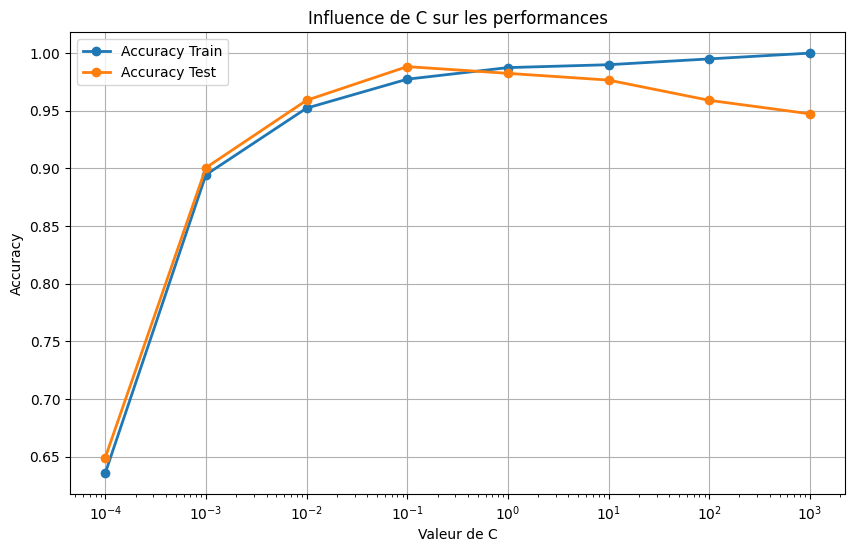

In [8]:
plt.figure(figsize=(10,6))

plt.plot(
    C_values,
    train_scores,
    marker='o',
    linewidth=2,
    label='Accuracy Train'
)

plt.plot(
    C_values,
    test_scores,
    marker='o',
    linewidth=2,
    label='Accuracy Test'
)

plt.xscale('log')

plt.xlabel("Valeur de C")
plt.ylabel("Accuracy")

plt.title("Influence de C sur les performances")

plt.grid(True)
plt.legend()

plt.show()

**ÉTAPE 3 : GridSearchCV**

In [9]:
param_grid = {
    'C': [
        0.0001,
        0.001,
        0.01,
        0.1,
        1,
        10,
        100,
        1000
    ]
}

Recherche automatique

In [10]:
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=10000),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(
    X_train_scaled,
    y_train
)

print("=" * 60)
print("RESULTATS GRIDSEARCHCV")
print("=" * 60)

print(
    "Meilleure valeur de C :",
    grid_search.best_params_['C']
)

print(
    "Meilleur score CV :",
    round(grid_search.best_score_,4)
)

RESULTATS GRIDSEARCHCV
Meilleure valeur de C : 1
Meilleur score CV : 0.9748


Évaluation finale

In [11]:
best_model = grid_search.best_estimator_

final_score = best_model.score(
    X_test_scaled,
    y_test
)

print("=" * 60)
print("ÉVALUATION FINALE")
print("=" * 60)

print(
    f"Accuracy finale sur le jeu de test : {final_score:.4f}"
)

ÉVALUATION FINALE
Accuracy finale sur le jeu de test : 0.9825


Visualisation des scores de validation croisée

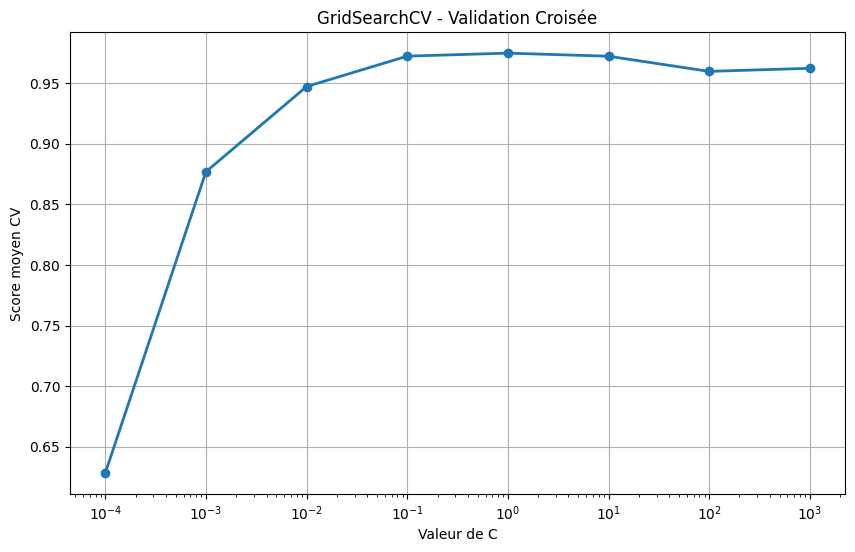

In [12]:
mean_scores = grid_search.cv_results_['mean_test_score']

plt.figure(figsize=(10,6))

plt.plot(
    C_values,
    mean_scores,
    marker='o',
    linewidth=2
)

plt.xscale('log')

plt.xlabel("Valeur de C")
plt.ylabel("Score moyen CV")

plt.title("GridSearchCV - Validation Croisée")

plt.grid(True)

plt.show()

ÉTAPE 4 : EXTENSION AVEC PÉNALITÉS L1 ET L2

In [13]:
# 1. Modification du dictionnaire pour chercher simultanément C et penalty
param_grid_extension = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'penalty': ['l1', 'l2']
}

# 2. Configuration incluant le solver 'liblinear' compatible avec L1 et L2
grid_search_extension = GridSearchCV(
    LogisticRegression(solver='liblinear', max_iter=10000),
    param_grid_extension,
    cv=5,
    scoring='accuracy'
)

# 3. Lancement de la recherche combinée
grid_search_extension.fit(X_train_scaled, y_train)

# Affichage des meilleurs résultats combinés
print("=== RÉSULTATS DE L'EXTENSION ===")
print(f"Meilleurs hyperparamètres trouvés : {grid_search_extension.best_params_}")
print(f"Meilleur score en validation croisée : {grid_search_extension.best_score_:.4f}")

# Évaluation FINALE de la meilleure combinaison sur le jeu de test
best_model_ext = grid_search_extension.best_estimator_
final_score_ext = best_model_ext.score(X_test_scaled, y_test)
print(f"Score final avec la combinaison optimale sur le jeu de test : {final_score_ext:.4f}")

=== RÉSULTATS DE L'EXTENSION ===
Meilleurs hyperparamètres trouvés : {'C': 0.1, 'penalty': 'l2'}
Meilleur score en validation croisée : 0.9774
Score final avec la combinaison optimale sur le jeu de test : 0.9942
